In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as mp

img = cv2.imread(r"C:\Users\Akshar Singh\Pictures\Screenshots\Screenshot 2026-07-24 153049.png")
print(type(img))

<class 'numpy.ndarray'>


In [4]:
print(img.shape)

(841, 1900, 3)


In [10]:
cv2.imshow("Photos", img)
cv2.waitKey(0)


-1

In [12]:
img_resize = cv2.resize(img,(400,256))
cv2.imshow("Photos", img_resize)
cv2.waitKey(0)

-1

In [13]:
img_flip = cv2.flip(img,0)
cv2.imshow("Photos", img_flip)
cv2.waitKey(0)

-1

In [15]:
img_crop = img[100:300, 200:500]
cv2.imshow("Photos", img_crop)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [18]:
import cv2
from ultralytics import settings

# Disable data and crash report tracking
settings.update({"sync": False})
from ultralytics import YOLO

# 1. Load the lightweight YOLOv8 Nano model (~6MB, runs fast on CPU)
model = YOLO('yolov8n.pt')

# 2. Open the webcam (0 is default built-in camera)
cap = cv2.VideoCapture(0)

print("Starting Object Counter... Press 'q' on the video window to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    print("Failed to grab camera frame.")
    break

  # 3. Perform object detection on the current frame
  results = model(frame, verbose=False)

  # Get total number of objects detected in this frame
  detected_count = len(results[0].boxes)

  # 4. Render detection boxes directly on the frame
  annotated_frame = results[0].plot()

  # 5. Display the object count overlay on screen
  cv2.putText(
      annotated_frame,
      f'Total Objects Counted: {detected_count}',
      (20, 50),  # Position (x, y)
      cv2.FONT_HERSHEY_SIMPLEX,
      1,  # Font scale
      (0, 255, 0),  # Text color (Green)
      2,  # Thickness
      cv2.LINE_AA,
  )

  # 6. Show the frame in a window
  cv2.imshow('BCA AI Demo - Live Object Counter', annotated_frame)

  # 7. Terminate program cleanly when pressing 'q'
  if cv2.waitKey(1) & 0xFF == ord('q'):
    print("Terminating program...")
    break

# Release camera and close all windows cleanly
cap.release()

# 2. Add short wait key loops to let Windows pump destroy events cleanly
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

print("Camera feed closed successfully.")
 

Starting Object Counter... Press 'q' on the video window to quit.
Terminating program...
Camera feed closed successfully.


In [20]:

import cv2
import numpy as np

# 1. Initialize Webcam (CAP_DSHOW prevents camera light freeze on Windows)
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

# 2. Define HSV Color Range for a BLUE object (Default)
# Tip: Adjust lower/upper bounds if using a Red/Green object!
LOWER_COLOR = np.array([100, 150, 0])  # Lower bound for Blue in HSV
UPPER_COLOR = np.array([140, 255, 255])  # Upper bound for Blue in HSV

canvas = None
prev_point = None

print("Air Canvas Started! Wave a BLUE marker in front of the camera to draw.")
print("Press 'c' to clear canvas. Press 'q' to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    break

  # Flip frame horizontally for intuitive "mirror" drawing
  frame = cv2.flip(frame, 1)

  # Initialize black canvas to match camera size on first frame
  if canvas is None:
    canvas = np.zeros_like(frame)

  # --- CORE CV CONCEPTS FOR STUDENTS ---

  # A. Convert BGR to HSV color space (easier to isolate specific colors)
  hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

  # B. Create binary mask (White = color detected, Black = background)
  mask = cv2.inRange(hsv, LOWER_COLOR, UPPER_COLOR)

  # Clean noise using morphological erosion and dilation
  mask = cv2.erode(mask, None, iterations=1)
  mask = cv2.dilate(mask, None, iterations=1)

  # C. Find contours (outlines of detected shapes)
  contours, _ = cv2.findContours(
      mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
  )

  curr_point = None

  if contours:
    # Get the largest contour (prevents small background noise from drawing)
    largest_contour = max(contours, key=cv2.contourArea)

    # Filter out tiny detections by minimum area threshold
    if cv2.contourArea(largest_contour) > 500:
      # Calculate centroid (center x, y coordinates) of detected marker
      M = cv2.moments(largest_contour)
      if M['m00'] != 0:
        cX = int(M['m10'] / M['m00'])
        cY = int(M['m01'] / M['m00'])
        curr_point = (cX, cY)

        # Draw a visual tracking dot around object tip
        cv2.circle(frame, curr_point, 8, (0, 255, 255), -1)

  # D. Draw lines on the canvas when object moves
  if curr_point and prev_point:
    cv2.line(canvas, prev_point, curr_point, (0, 0, 255), 5)  # Red ink line

  prev_point = curr_point

  # Combine live webcam feed and drawing canvas together
  combined = cv2.add(frame, canvas)

  # Display UI instructions
  cv2.putText(
      combined,
      "Press 'c' to Clear | Press 'q' to Quit",
      (10, 30),
      cv2.FONT_HERSHEY_SIMPLEX,
      0.7,
      (255, 255, 255),
      2,
  )

  cv2.imshow('BCA AI Demo - Virtual Air Canvas', combined)

  key = cv2.waitKey(1) & 0xFF
  if key == ord('c'):
    canvas = np.zeros_like(frame)  # Clear canvas
  elif key == ord('q'):
    break

# Clean up webcam resources cleanly
cap.release()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)
 

Air Canvas Started! Wave a BLUE marker in front of the camera to draw.
Press 'c' to clear canvas. Press 'q' to quit.


-1

In [16]:
# Import necessary libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Ensure necessary NLTK data is downloaded
nltk.download('punkt_tab')  # Changed from 'punkt' to 'punkt_tab'
nltk.download('stopwords')

# Provided text
text = """
My life is a beautiful journey filled with continuous learning, meaningful connections, and a deep appreciation for the present moment. I believe that every experience, whether a triumph or a challenge, shapes my character and guides my personal growth. Every day, I strive to balance my responsibilities with my passions, ensuring that I dedicate time to my loved ones, my career or studies, and the hobbies that bring me genuine joy.I approach life with a mindset of curiosity and gratitude, finding inspiration in both the grand milestones and the quiet, ordinary moments. Cultivating resilience has taught me to navigate setbacks with patience, viewing them not as roadblocks but as opportunities to redirect and strengthen myself. Ultimately, my primary goal is to live authentically, make a positive impact on the people around me, and create a lasting collection of happy, fulfilling memories. I am constantly evolving, and I embrace the future with optimism and an open heart, ready for whatever adventures come next.
"""

words = word_tokenize(text.lower())  # This will now run successfully
print(words)


['my', 'life', 'is', 'a', 'beautiful', 'journey', 'filled', 'with', 'continuous', 'learning', ',', 'meaningful', 'connections', ',', 'and', 'a', 'deep', 'appreciation', 'for', 'the', 'present', 'moment', '.', 'i', 'believe', 'that', 'every', 'experience', ',', 'whether', 'a', 'triumph', 'or', 'a', 'challenge', ',', 'shapes', 'my', 'character', 'and', 'guides', 'my', 'personal', 'growth', '.', 'every', 'day', ',', 'i', 'strive', 'to', 'balance', 'my', 'responsibilities', 'with', 'my', 'passions', ',', 'ensuring', 'that', 'i', 'dedicate', 'time', 'to', 'my', 'loved', 'ones', ',', 'my', 'career', 'or', 'studies', ',', 'and', 'the', 'hobbies', 'that', 'bring', 'me', 'genuine', 'joy.i', 'approach', 'life', 'with', 'a', 'mindset', 'of', 'curiosity', 'and', 'gratitude', ',', 'finding', 'inspiration', 'in', 'both', 'the', 'grand', 'milestones', 'and', 'the', 'quiet', ',', 'ordinary', 'moments', '.', 'cultivating', 'resilience', 'has', 'taught', 'me', 'to', 'navigate', 'setbacks', 'with', 'pati

[nltk_data] Downloading package punkt_tab to C:\Users\Akshar
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Akshar
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
# The general syntax for a list comprehension is: [expression for item in iterable if condition]
print(filtered_words)

['life', 'beautiful', 'journey', 'filled', 'continuous', 'learning', 'meaningful', 'connections', 'deep', 'appreciation', 'present', 'moment', 'believe', 'every', 'experience', 'whether', 'triumph', 'challenge', 'shapes', 'character', 'guides', 'personal', 'growth', 'every', 'day', 'strive', 'balance', 'responsibilities', 'passions', 'ensuring', 'dedicate', 'time', 'loved', 'ones', 'career', 'studies', 'hobbies', 'bring', 'genuine', 'approach', 'life', 'mindset', 'curiosity', 'gratitude', 'finding', 'inspiration', 'grand', 'milestones', 'quiet', 'ordinary', 'moments', 'cultivating', 'resilience', 'taught', 'navigate', 'setbacks', 'patience', 'viewing', 'roadblocks', 'opportunities', 'redirect', 'strengthen', 'ultimately', 'primary', 'goal', 'live', 'authentically', 'make', 'positive', 'impact', 'people', 'around', 'create', 'lasting', 'collection', 'happy', 'fulfilling', 'memories', 'constantly', 'evolving', 'embrace', 'future', 'optimism', 'open', 'heart', 'ready', 'whatever', 'advent

In [18]:
# Create a WordCloud
word_freq = Counter(filtered_words) 
print(word_freq)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

Counter({'life': 2, 'every': 2, 'beautiful': 1, 'journey': 1, 'filled': 1, 'continuous': 1, 'learning': 1, 'meaningful': 1, 'connections': 1, 'deep': 1, 'appreciation': 1, 'present': 1, 'moment': 1, 'believe': 1, 'experience': 1, 'whether': 1, 'triumph': 1, 'challenge': 1, 'shapes': 1, 'character': 1, 'guides': 1, 'personal': 1, 'growth': 1, 'day': 1, 'strive': 1, 'balance': 1, 'responsibilities': 1, 'passions': 1, 'ensuring': 1, 'dedicate': 1, 'time': 1, 'loved': 1, 'ones': 1, 'career': 1, 'studies': 1, 'hobbies': 1, 'bring': 1, 'genuine': 1, 'approach': 1, 'mindset': 1, 'curiosity': 1, 'gratitude': 1, 'finding': 1, 'inspiration': 1, 'grand': 1, 'milestones': 1, 'quiet': 1, 'ordinary': 1, 'moments': 1, 'cultivating': 1, 'resilience': 1, 'taught': 1, 'navigate': 1, 'setbacks': 1, 'patience': 1, 'viewing': 1, 'roadblocks': 1, 'opportunities': 1, 'redirect': 1, 'strengthen': 1, 'ultimately': 1, 'primary': 1, 'goal': 1, 'live': 1, 'authentically': 1, 'make': 1, 'positive': 1, 'impact': 1,

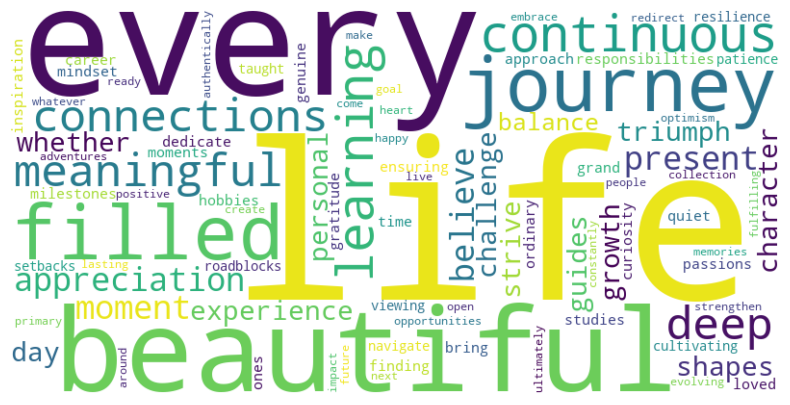

In [19]:
# Plotting the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.show()